In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
# J neural interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
file_path = os.path.join(base_path, 'J_neu.pkl')
with open(file_path, "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

# N neural interpPSTH
file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

# J neural mean firing rates
file_path = os.path.join(base_path, 'J_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_FR = pickle.load(input_file)
del input_file

# N neural mean firing rates
file_path = os.path.join(base_path, 'N_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    N_pickle_FR = pickle.load(input_file)
del input_file

# J muscle interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

# N muscle interpPSTH
ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# J muscle mean firing rates
file_path = os.path.join(base_path, 'muscle_J_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_m_FR = pickle.load(input_file)
del input_file

# N msucle mean firing rates
ile_path = os.path.join(base_path, 'muscle_N_FR.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m_FR = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

# INTER P PSTH
J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']

N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

# MEAN FR
J_all_FR = J_pickle_FR['J_all_FR']['mean_FR']
J_M1_FR = J_pickle_FR['J_M1_FR']['mean_FR']
J_PMd_FR = J_pickle_FR['J_PMd_FR']['mean_FR']
J_idx = np.r_[0:18, 36:45]
J_ntm_FR = J_all_FR[J_idx, :, :]
J_mus_FR = J_pickle_m_FR['mean_FR']

N_all_FR = N_pickle_FR['N_all_FR']['mean_FR']
N_M1_FR = N_pickle_FR['N_M1_FR']['mean_FR']
N_PMd_FR = N_pickle_FR['N_PMd_FR']['mean_FR']
N_mus_FR = N_pickle_m_FR['mean_FR']


<>:28: SyntaxWarning: invalid escape sequence '\J'
<>:28: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_23216\2881311274.py:28: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[ 6 12 24 16  0 15 14  9  5 23 17  3 18  1 26 20 11  4  8  7 21 13]
>>> best_lam returning: 7.017038286703837
frac null:  0.7657963943763068
frac potent:  0.23420360562369413


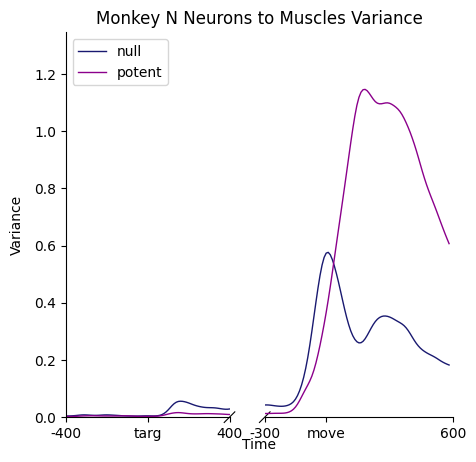

In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[10 24 22 25  2 21 11 20 16  1 13  3 14 12 23 15  7 26  8 17  9  4]
>>> best_lam returning: 100.0
frac null:  0.6079441574456257
frac potent:  0.39205584255437587


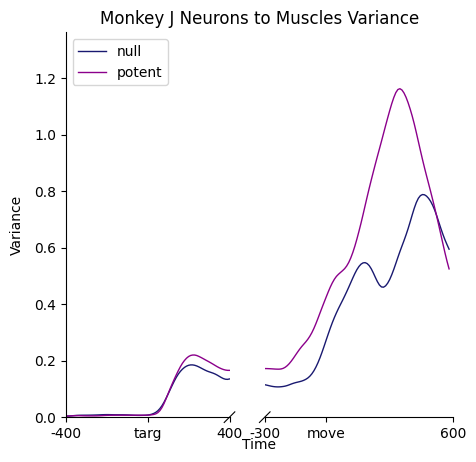

In [4]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[15 26  1  0  7 20  8 25 12 18 24  2  9 21 16 23 10  3  4 17  6 14]
>>> best_lam returning: 4.124626382901356
frac null:  0.5687211247079039
frac potent:  0.43127887529209735


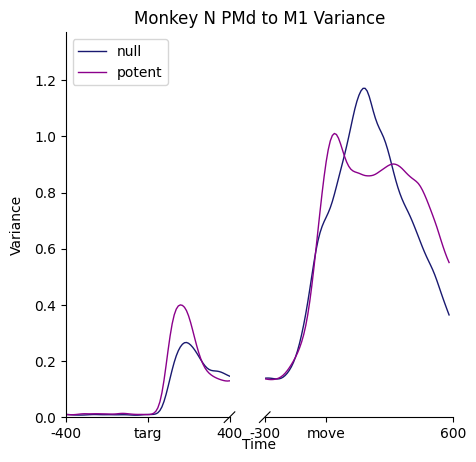

In [5]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[21 13  1  2 23 14  5 20  3 11  8 16 19 25 15 24 26  0  4 18 22 17]
>>> best_lam returning: 20.30917620904739
[ 7 23  5  3 11 18 21  0 16 15 10  2 19  4 17 13 25  1 14  6  8 26]
>>> best_lam returning: 20.30917620904739
[13  2 26  9 24 18  4 25 20  0 19 22  8  7 16  1 23 17  6 10 21 15]
>>> best_lam returning: 34.55107294592218
[ 4 10 17  3  8 12 26 18 14 13  1 21  9  7 16  0  6 24 15 19 20 25]
>>> best_lam returning: 20.30917620904739
frac null:  0.5702870405486684
frac potent:  0.42971295945133087


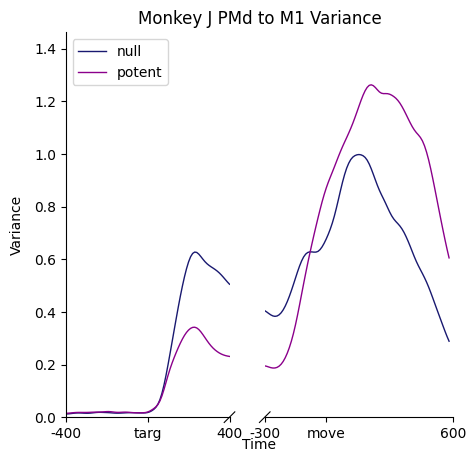

In [6]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[15 18  4  7  6  5  0 10  8 24 19  9 25 26 16  2 13 11 20 14 23 17]
>>> best_lam returning: 20.30917620904739
[ 0 21 19 15 14 10 24 18  1  5  2  4  9  6 26  7 25 23 12  3 16 17]
>>> best_lam returning: 20.30917620904739
[ 9  3 18 26 24 21  2 22  5  8 10  6 13 16  4 19 25 11 14 15 23 17]
>>> best_lam returning: 20.30917620904739
[ 1 20  3 14  0 22 10 15 25  6 18 23  8 19 16 24  2  9 13  7  5 26]
>>> best_lam returning: 20.30917620904739
frac null:  0.5738006608055819
frac potent:  0.4261993391944173


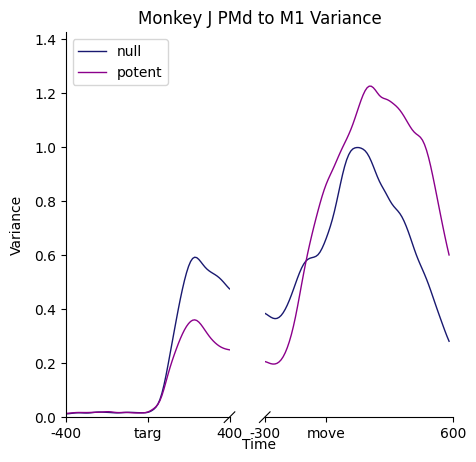

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 0  4  3 15 12  6  2  5 10 21 13 22 14 17  9 18 23 26  7 16 20 11]
>>> best_lam returning: 20.30917620904739
frac null:  0.7669363566569137
frac potent:  0.23306364334308738


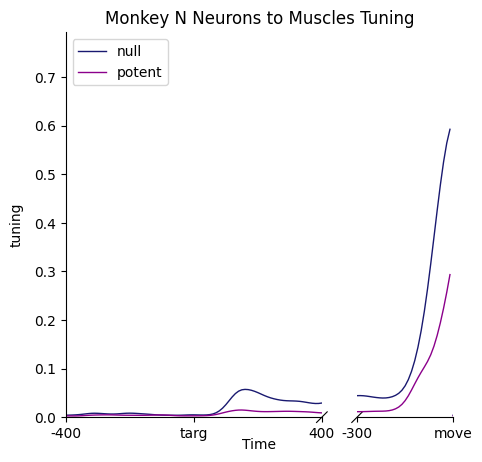

In [8]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)